<h1> Download dataset

In [ ]:
import gdown
import os

# Tạo thư mục để chứa dữ liệu
os.makedirs('/content/my_data', exist_ok=True)

# Download hoặc mount folder cụ thể
folder_url = 'https://drive.google.com/drive/folders/1nVbqhB0bxLGrc6Pa8z8bHrdsO-amxfvb'

# Cách 2.1: Sử dụng gdown cho folder
!gdown --folder https://drive.google.com/drive/folders/1nVbqhB0bxLGrc6Pa8z8bHrdsO-amxfvb -O /content/my_data

Retrieving folder contents
Retrieving folder 1TKTvk6SYAZQiVduVOSu96qgzT4NjslYQ animal
Processing file 1NcmW6HtLKSUgCe_X_MBd9OPPsOmj1tA3 data.csv
Retrieving folder 1noJEYCu5yZbhetoHzYk05nlOdz-ZT9pn customer_behaviour
Processing file 1GL_uKTPy2UdEBYst6lbNG9KvhcAKOP7C Customer_Behaviour.csv
Retrieving folder 1o7UtpJteRXSzcSskBtld_YELt78UdGJp diabetes
Processing file 14jNxrivpX3pOtdzRPfgQK4zhdL37qHr7 diabetes_prediction_dataset.csv
Retrieving folder 1FagU_swQdjzHOwTRXff0Mm7qo8kf-Hb4 mushroom
Processing file 17vfEPMwf-N1rhSTGl8MwBvJFCMdpG1It mushrooms.csv
Retrieving folder 1q-ox-JLmxpPlvno_il7HchhzV7QtpciW titanic
Processing file 1j4F38EOOZN3FBIE19rMRKoetGRQ3MvRj gender_submission.csv
Processing file 1_vYdLK7ngcFVDxWsgKJdBUAuQUWqS7h6 test.csv
Processing file 173PCI9sqaoW1XLqKX8Tk6WOr-R5_VbFQ train.csv
Retrieving folder contents completed
Building directory structure
Building directory structure completed
Downloading...
From: https://drive.google.com/uc?id=1NcmW6HtLKSUgCe_X_MBd9OPPsOmj1tA3
T

# GIẢI THUẬT 1: CÂY QUYẾT ĐỊNH VÀ RỪNG CÂY

## Bài tập thực hành

### Bài 1: Xây dựng cây quyết định và rừng cây trên
dữ liệu Titanic lấy từ: https://www.kaggle.com/code/dmilla/introduction-to-decision-trees-titanic-dataset

### Xây dựng cây quyết định

#### 1.1. Tải một số package và package graphviz, để vẽ cây quyết định

In [ ]:
import numpy as np #numerical computation
import pandas as pd #data wrangling
import matplotlib.pyplot as plt #plotting package
#Next line helps with rendering plots
%matplotlib inline
import matplotlib as mpl #add'l plotting functionality
mpl.rcParams['figure.dpi'] = 400 #high res figures
import graphviz #to visualize decision trees

#### 1.2. Nạp dữ liệu vào bộ nhớ, phân tích và loại bỏ những features không liên quan đến bài toán cần giải quyết

In [ ]:
df = pd.read_csv('/content/my_data/titanic/train.csv') #Load the cleaned data
df_test = pd.read_csv('/content/my_data/titanic/test.csv') #Load the cleaned data

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [ ]:
df_test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  418 non-null    int64  
 1   Pclass       418 non-null    int64  
 2   Name         418 non-null    object 
 3   Sex          418 non-null    object 
 4   Age          332 non-null    float64
 5   SibSp        418 non-null    int64  
 6   Parch        418 non-null    int64  
 7   Ticket       418 non-null    object 
 8   Fare         417 non-null    float64
 9   Cabin        91 non-null     object 
 10  Embarked     418 non-null    object 
dtypes: float64(2), int64(4), object(5)
memory usage: 36.1+ KB


In [ ]:
features_response = df.columns.tolist() #Get a list of column names
#Make a list of columns to remove that aren't features or the response variable
items_to_remove = ['Cabin', 'Ticket', 'Name', 'PassengerId']
features_response = [item for item in features_response if item not in items_to_remove]
features_response

['Survived', 'Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked']

In [ ]:
cls_sex = {'male':0, 'female':1}
df['Sex'] = df['Sex'].apply(lambda x:cls_sex[x])
df_test['Sex'] = df_test['Sex'].apply(lambda x:cls_sex[x])

cls_embarked = {'S':0, 'C':1, 'Q':2}
df['Embarked'] = df['Embarked'].apply(lambda x: cls_embarked[x] if pd.isna(x) == False else cls_embarked['S'])
df_test['Embarked'] = df_test['Embarked'].apply(lambda x: cls_embarked[x] if pd.isna(x) == False else cls_embarked['S'])

fillna_cols = ['Age', 'Fare']
df[fillna_cols] = df[fillna_cols].fillna(df[fillna_cols].mean())
df_test[fillna_cols] = df_test[fillna_cols].fillna(df_test[fillna_cols].mean())

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    int64  
 5   Age          891 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     891 non-null    int64  
dtypes: float64(2), int64(7), object(3)
memory usage: 83.7+ KB


In [ ]:
X = df[features_response[1:]].values
y = df['Survived'].values

#### 1.3. Chuẩn bị dữ liệu cho tập train và tập test

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn import tree
#Split the data into training and testing sets using the same random seed
X_train, X_test, y_train, y_test = \
train_test_split(X, y, test_size=0.2, random_state=24)

#### 1.4. Xây dựng cây quyết định từ lớp DecisionTreeClassifier có trong thư viện Scikit-Learn

In [ ]:
# the tree will grow to a depth of at most 2
dt = tree.DecisionTreeClassifier(max_depth=2)
dt.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=2)

#### 1.5. Hiển thị cây quyết định với package graphviz

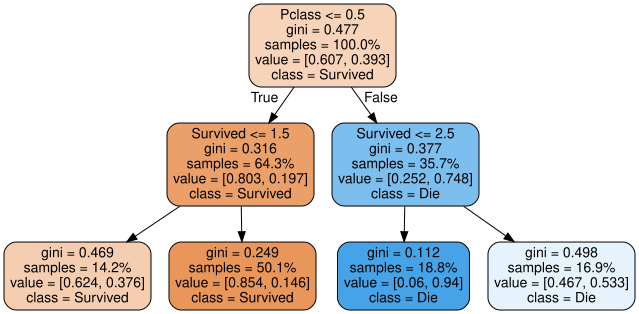

In [ ]:
dot_data = tree.export_graphviz(dt,
out_file=None,
filled=True,
rounded=True,
feature_names=\
features_response[:-1],
proportion=True,
class_names=['Survived', 'Die'])
graph = graphviz.Source(dot_data)
graph

### Tìm tham số tối ưu cho cây quyết định bằng GridSearchCV và vẽ biểu đồ đánh giá mô hình với các tham số khác nhau



#### 1.6. Tìm tham số tối ưu bằng GridSearchCV


In [ ]:
from sklearn.model_selection import GridSearchCV
params = {'max_depth':[1, 2, 4, 6, 8, 10, 12]} #parameters
dt = tree.DecisionTreeClassifier() #tree modal
cv = GridSearchCV(dt, param_grid=params, scoring='roc_auc',
n_jobs=None, refit=True, cv=4, verbose=1,
error_score=np.nan,
return_train_score=True) # cv is the best model.
cv.fit(X_train, y_train)

Fitting 4 folds for each of 7 candidates, totalling 28 fits


GridSearchCV(cv=4, estimator=DecisionTreeClassifier(),
             param_grid={'max_depth': [1, 2, 4, 6, 8, 10, 12]},
             return_train_score=True, scoring='roc_auc', verbose=1)

#### 1.7. Vẽ biểu đồ đánh giá mô hình với các tham số chiều sâu của cây khác nhau

<>:8: SyntaxWarning: invalid escape sequence '\p'
<>:12: SyntaxWarning: invalid escape sequence '\p'
<>:8: SyntaxWarning: invalid escape sequence '\p'
<>:12: SyntaxWarning: invalid escape sequence '\p'
/tmp/ipython-input-1478637665.py:8: SyntaxWarning: invalid escape sequence '\p'
  label='Mean $\pm$ 1 SE training scores')
/tmp/ipython-input-1478637665.py:12: SyntaxWarning: invalid escape sequence '\p'
  label='Mean $\pm$ 1 SE testing scores')


Text(0, 0.5, 'ROC AUC')

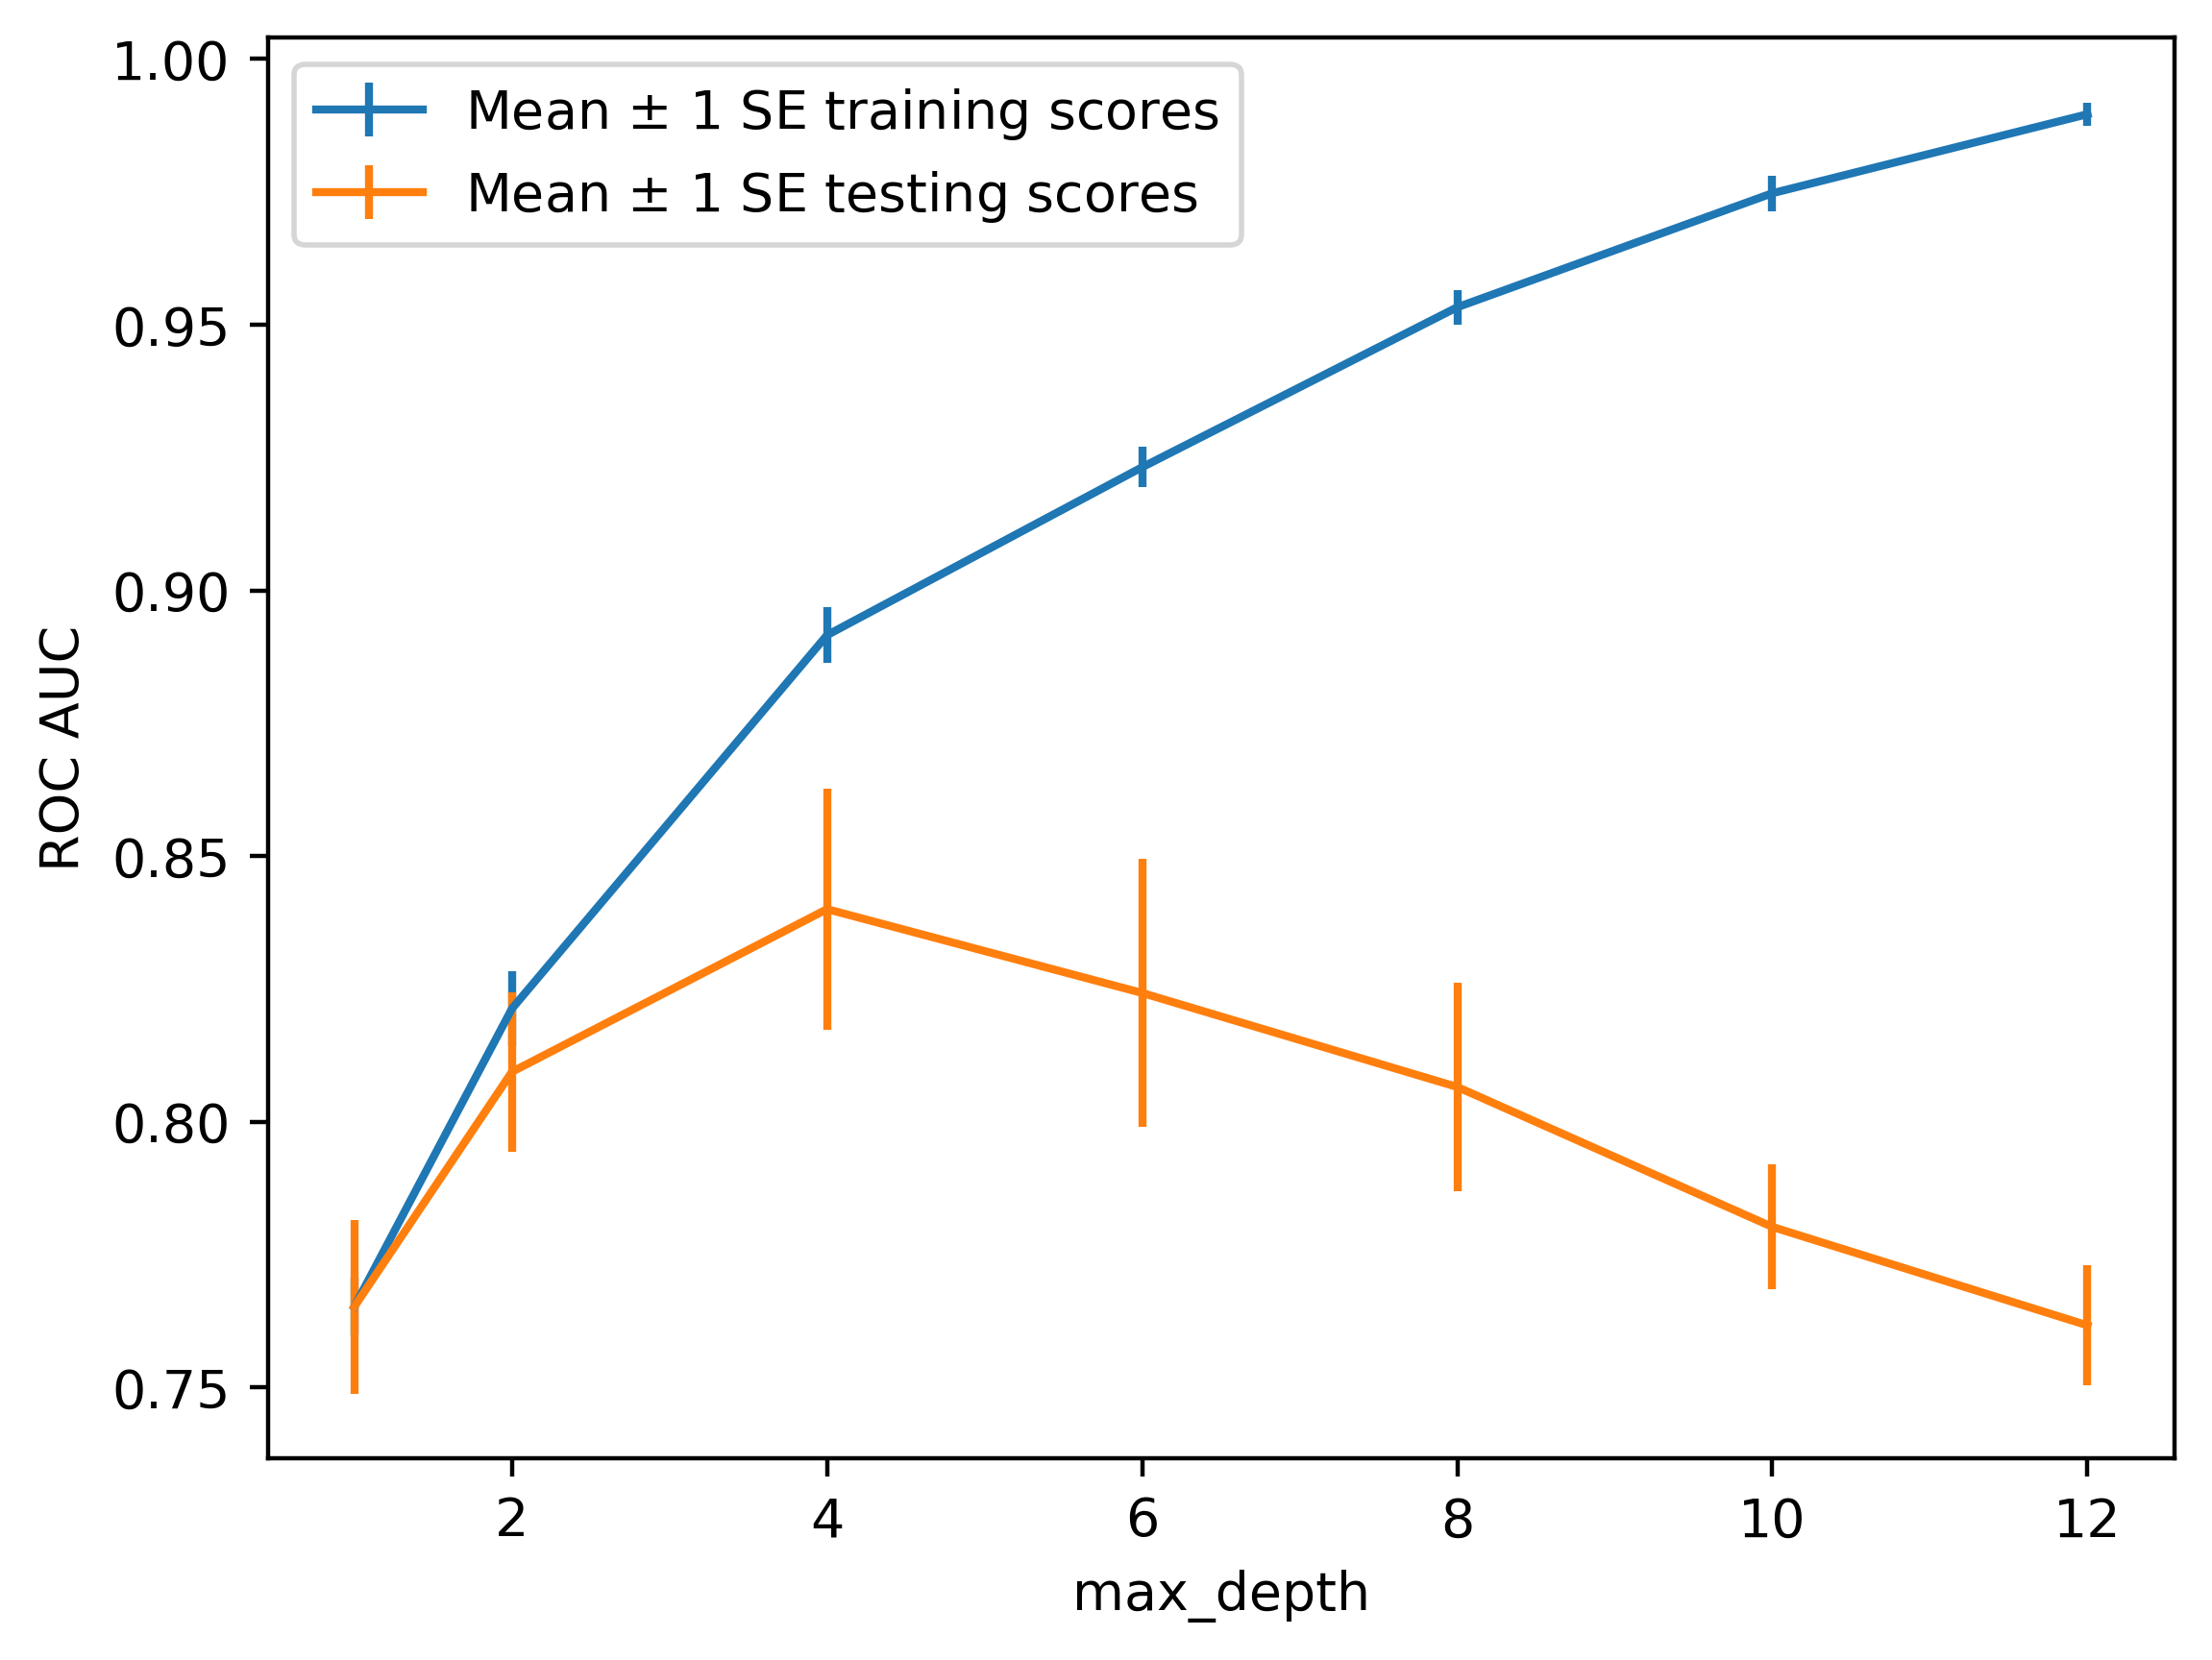

In [ ]:
cv_results_df = pd.DataFrame(cv.cv_results_)
#View the names of the remaining columns in the results DataFrame
cv_results_df.columns
ax = plt.axes()
ax.errorbar(cv_results_df['param_max_depth'],
cv_results_df['mean_train_score'],
yerr=cv_results_df['std_train_score']/np.sqrt(4),
label='Mean $\pm$ 1 SE training scores')
ax.errorbar(cv_results_df['param_max_depth'],
cv_results_df['mean_test_score'],
yerr=cv_results_df['std_test_score']/np.sqrt(4),
label='Mean $\pm$ 1 SE testing scores')
ax.legend()
plt.xlabel('max_depth')
plt.ylabel('ROC AUC')

### Xây dựng rừng cây (Random Forest)

#### 1.8. Tạo rừng cây với lớp RandomForestClassifier trong Scikit-Learn

In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier\
(n_estimators=10, criterion='gini', max_depth=3,
min_samples_split=2, min_samples_leaf=1, min_weight_fraction_leaf=0.0,
max_features='sqrt', max_leaf_nodes=None, min_impurity_decrease=0.0,
bootstrap=True, oob_score=False, n_jobs=None,
random_state=4, verbose=0, warm_start=False, class_weight=None)

#### 1.9. Tìm tham số tối ưu cho mô hình rừng cây và thực hiện train với tham số tối ưu đó

In [ ]:
#a parameter grid for this exercise in order to search the numbers of trees, ranging from 10 to 100 by 10s
rf_params_ex = {'n_estimators':list(range(10,110,10))}
cv_rf_ex = GridSearchCV(rf, param_grid=rf_params_ex,
scoring='roc_auc', n_jobs=None,
refit=True, cv=4, verbose=1,
error_score=np.nan,
return_train_score=True)

cv_rf_ex.fit(X_train, y_train)

Fitting 4 folds for each of 10 candidates, totalling 40 fits


GridSearchCV(cv=4,
             estimator=RandomForestClassifier(max_depth=3, n_estimators=10,
                                              random_state=4),
             param_grid={'n_estimators': [10, 20, 30, 40, 50, 60, 70, 80, 90,
                                          100]},
             return_train_score=True, scoring='roc_auc', verbose=1)

#### 1.10. Vẽ biểu đồ đánh giá mô hình rừng cây với các tham số số cây có trong rừng khác nhau

<>:12: SyntaxWarning: invalid escape sequence '\p'
<>:12: SyntaxWarning: invalid escape sequence '\p'
/tmp/ipython-input-1889697650.py:12: SyntaxWarning: invalid escape sequence '\p'
  axs[1].set_ylabel('Mean testing ROC AUC $\pm$ 1 SE ')


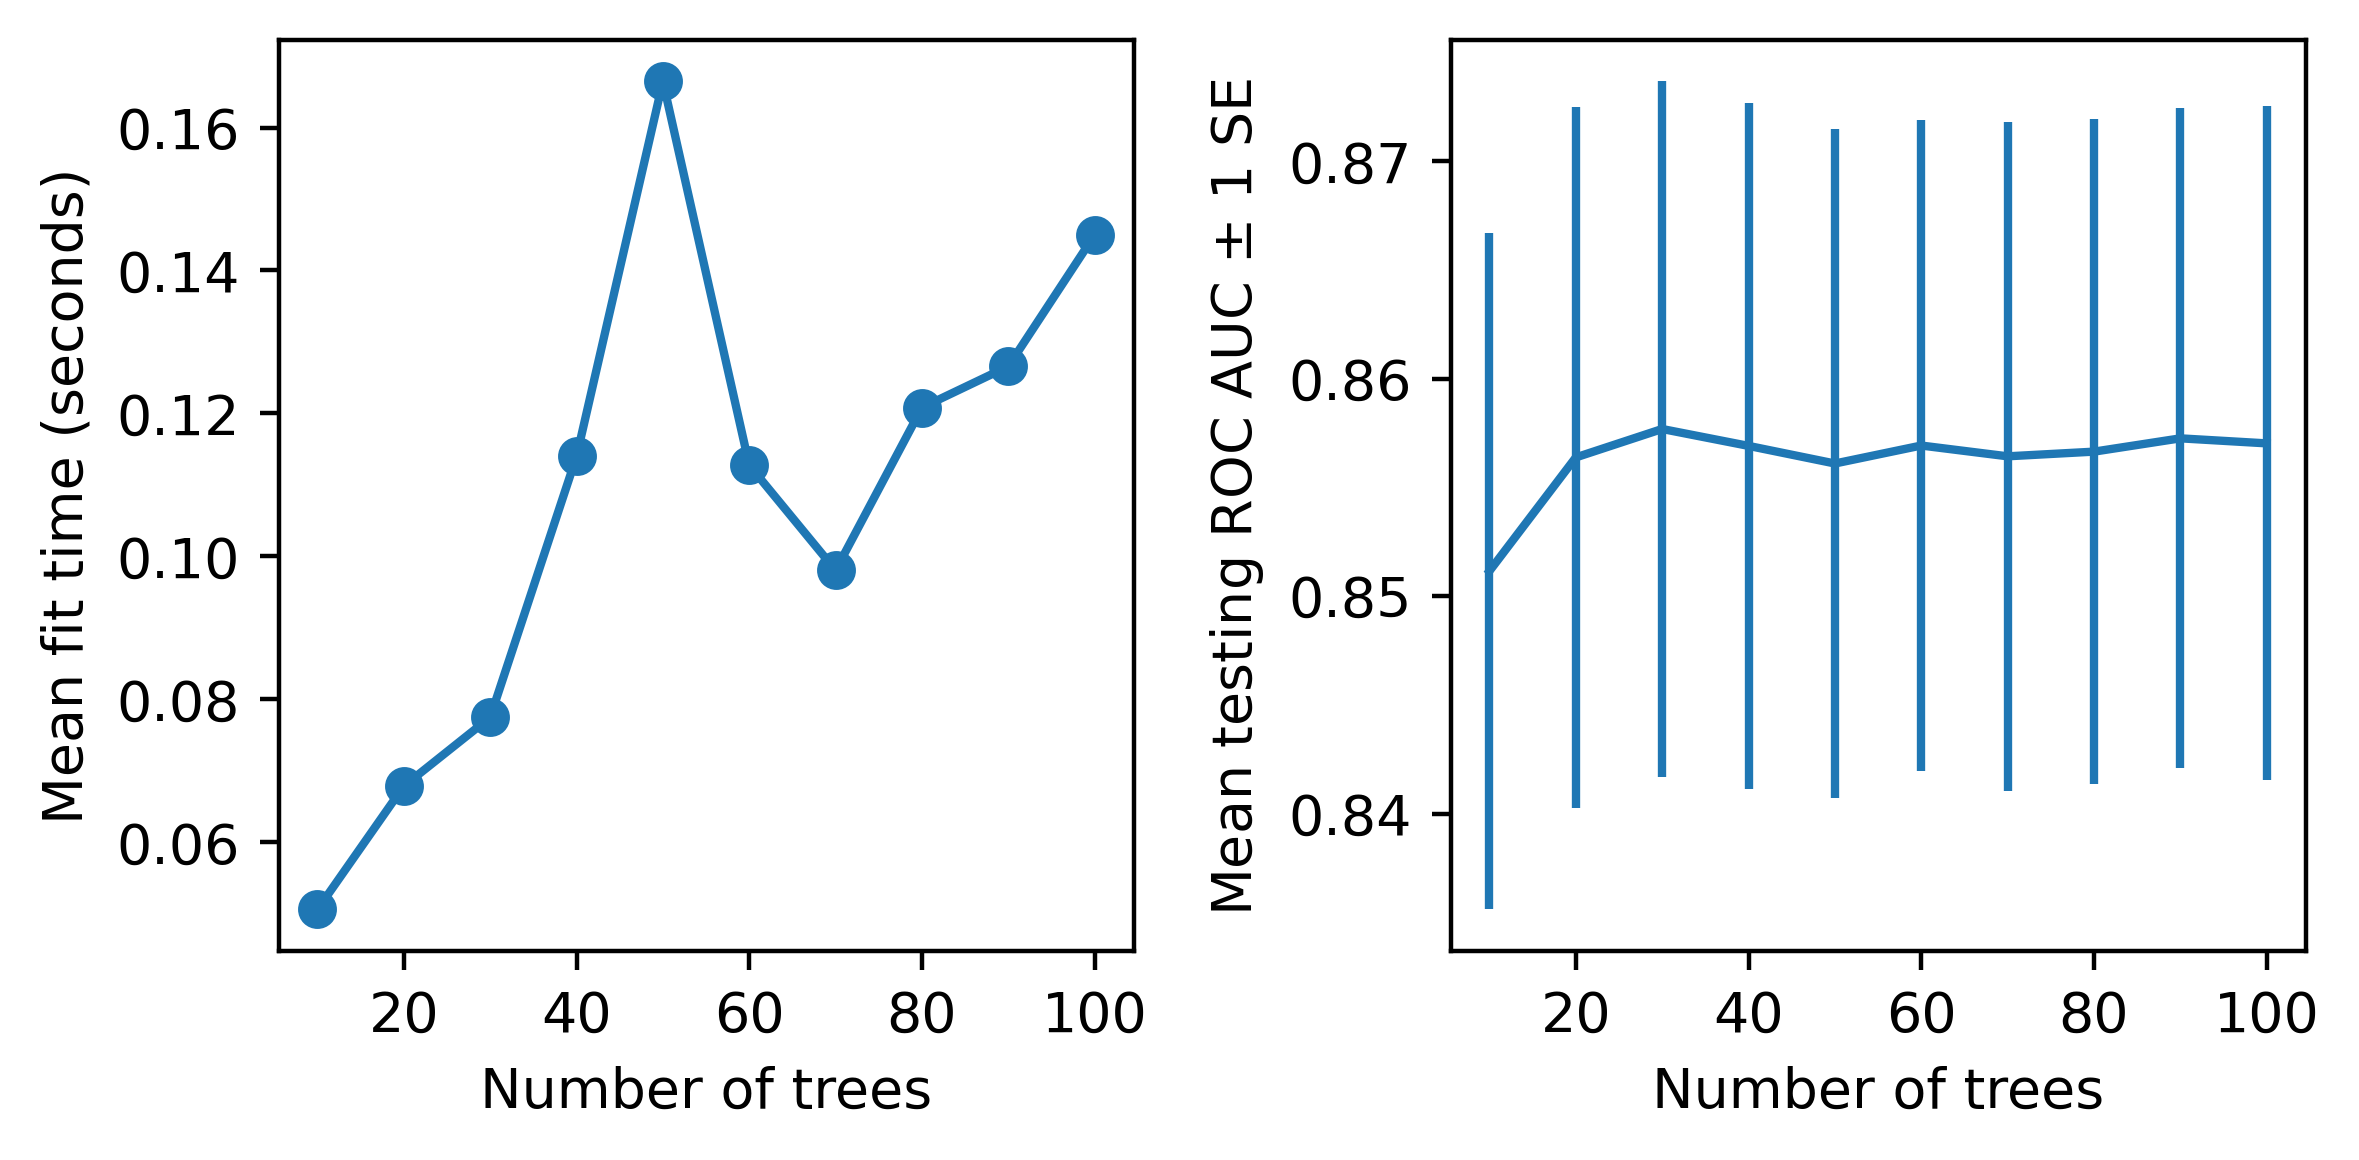

In [ ]:
cv_rf_ex_results_df = pd.DataFrame(cv_rf_ex.cv_results_)
fig, axs = plt.subplots(nrows=1, ncols=2, figsize=(6, 3))
axs[0].plot(cv_rf_ex_results_df['param_n_estimators'],
cv_rf_ex_results_df['mean_fit_time'],
'-o')
axs[0].set_xlabel('Number of trees')
axs[0].set_ylabel('Mean fit time (seconds)')
axs[1].errorbar(cv_rf_ex_results_df['param_n_estimators'],
cv_rf_ex_results_df['mean_test_score'],
yerr=cv_rf_ex_results_df['std_test_score']/np.sqrt(4))
axs[1].set_xlabel('Number of trees')
axs[1].set_ylabel('Mean testing ROC AUC $\pm$ 1 SE ')
plt.tight_layout()

#### 1.11. Xem tham số tốt nhất của rừng cây, xem mức độ quan trọng của từng feature trong mô hình với tham số tốt nhất

In [ ]:
cv_rf_ex.best_params_

{'n_estimators': 30}

<Axes: >

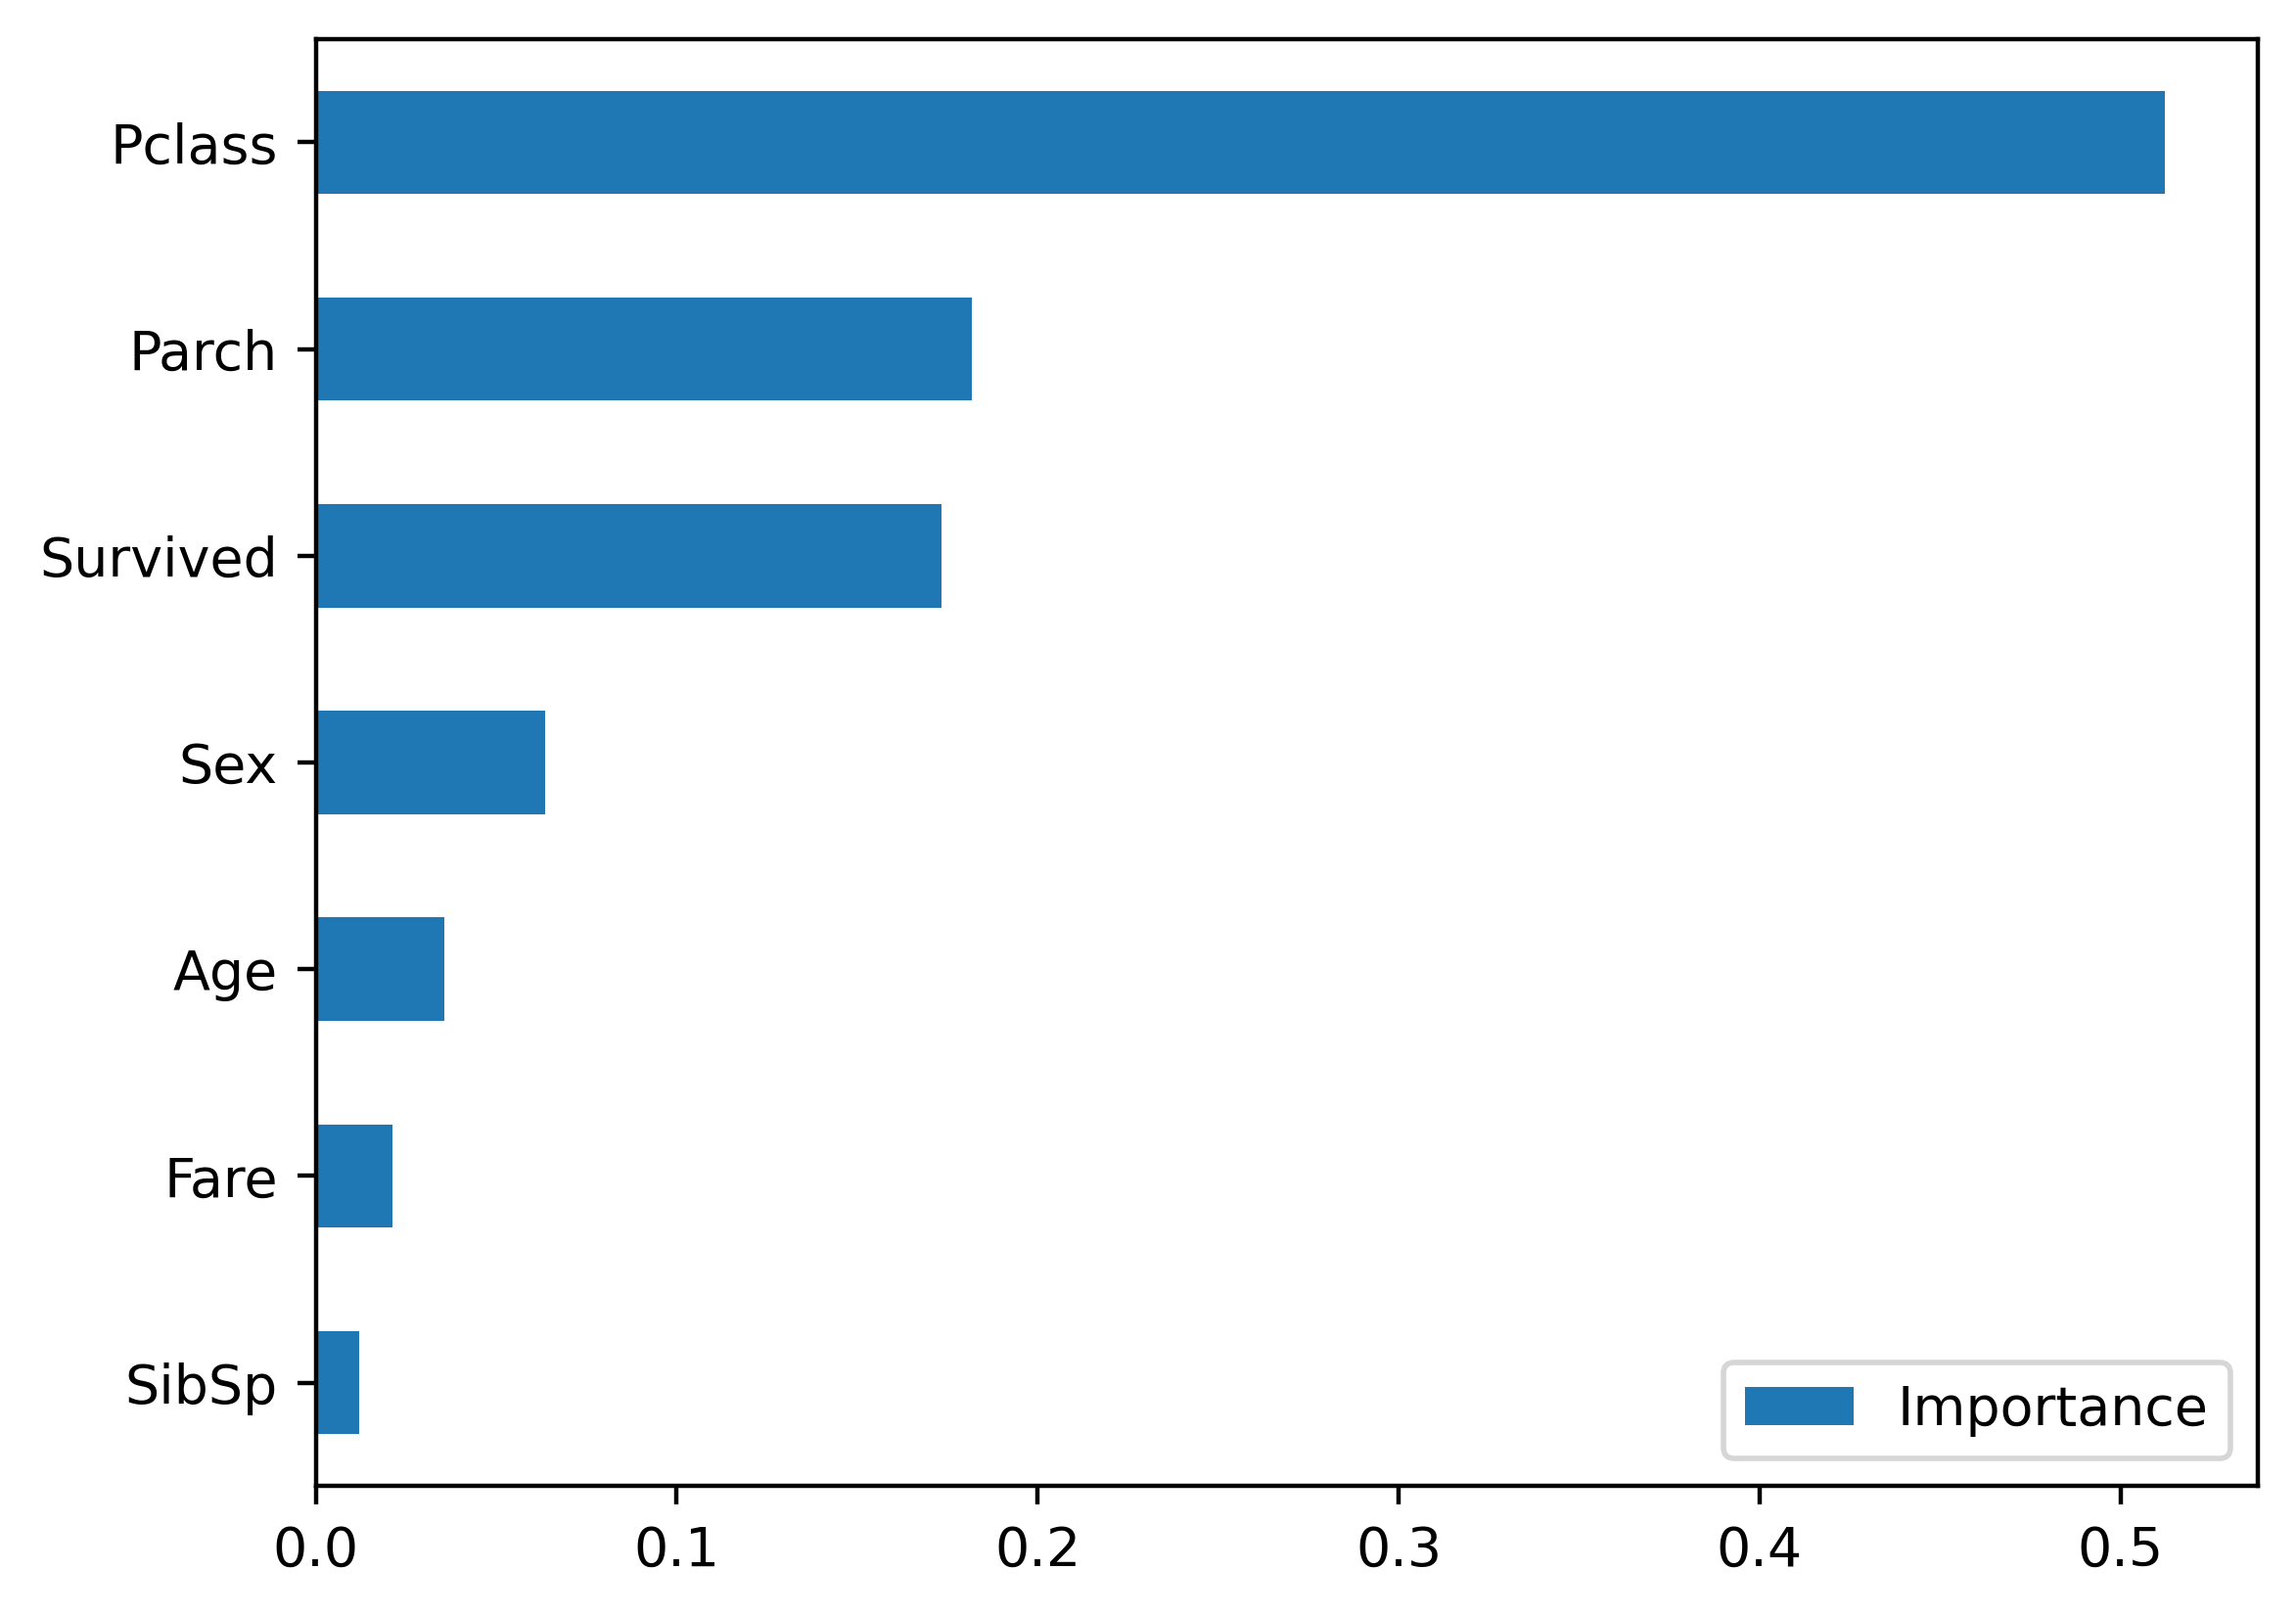

In [ ]:
# the feature names and importances
feat_imp_df = pd.DataFrame({
'Importance':cv_rf_ex.best_estimator_.feature_importances_},
index=features_response[:-1])
feat_imp_df.sort_values('Importance', ascending=True).plot.barh()

### Bài 2: Xây dựng cây quyết định và rừng cây trên dữ liệu bệnh tiểu đường.
Dữ liệu lấy từ: https://www.kaggle.com/code/tumpanjawat/diabetes-eda-random-forest-hp

### Xây dựng cây quyết định

#### 2.1. Tải một số package và package graphviz, để vẽ cây quyết định

In [ ]:
!pip install graphviz

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 47.3/47.3 kB 2.2 MB/s eta 0:00:00


In [ ]:
import numpy as np #numerical computation
import pandas as pd #data wrangling
import matplotlib.pyplot as plt #plotting package
#Next line helps with rendering plots
%matplotlib inline
import matplotlib as mpl #add'l plotting functionality
mpl.rcParams['figure.dpi'] = 400 #high res figures
import graphviz #to visualize decision trees

#### 2.2. Nạp dữ liệu vào bộ nhớ, phân tích và loại bỏ những features không liên quan đến bài toán cần giải quyết

In [ ]:
df = pd.read_csv('/content/my_data/diabetes/diabetes_prediction_dataset.csv') #Load the cleaned data

In [ ]:
features_response = df.columns.tolist() #Get a list of column names
#Make a list of columns to remove that aren't features or the response variable
items_to_remove = []
features_response = [item for item in features_response if item not
in items_to_remove]
features_response

['gender',
 'age',
 'hypertension',
 'heart_disease',
 'smoking_history',
 'bmi',
 'HbA1c_level',
 'blood_glucose_level',
 'diabetes']

#### 2.3. Chuẩn bị dữ liệu cho tập train và tập test

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn import tree

# 1️⃣ Xác định features và target
features = df.drop(columns=['diabetes'])
target = df['diabetes']

# 2️⃣ Encode categorical columns (gender, smoking_history)
features_encoded = pd.get_dummies(features)

# 3️⃣ Chia train/test
X_train, X_test, y_train, y_test = train_test_split(
    features_encoded.values,  # dùng dữ liệu đã encode
    target.values,
    test_size=0.2,
    random_state=24
)

#### 2.4. Xây dựng cây quyết định từ lớp DecisionTreeClassifier có trong thư viện Scikit-Learn

In [ ]:
# the tree will grow to a depth of at most 2
dt = tree.DecisionTreeClassifier(max_depth=2)
dt.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=2)

#### 2.5. Hiển thị cây quyết định với package graphviz

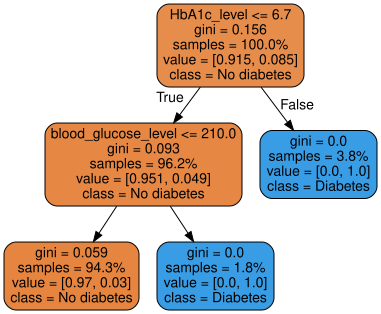

In [ ]:
feature_names = features_encoded.columns.tolist()  # 15 cột

dot_data = tree.export_graphviz(
    dt,
    out_file=None,
    filled=True,
    rounded=True,
    feature_names=feature_names,     # dùng tên cột encode
    proportion=True,
    class_names=['No diabetes', 'Diabetes']
)

import graphviz
graph = graphviz.Source(dot_data)
graph

### Tìm tham số tối ưu cho cây quyết định bằng GridSearchCV và vẽ biểu đồ đánh giá mô hình với các tham số khác nhau



#### 2.6. Tìm tham số tối ưu bằng GridSearchCV


In [ ]:
from sklearn.model_selection import GridSearchCV
params = {'max_depth':[1, 2, 4, 6, 8, 10, 12]} #parameters
dt = tree.DecisionTreeClassifier() #tree modal
cv = GridSearchCV(dt, param_grid=params, scoring='roc_auc',
n_jobs=None, refit=True, cv=4, verbose=1,
error_score=np.nan,
return_train_score=True) # cv is the best model.
cv.fit(X_train, y_train)

Fitting 4 folds for each of 7 candidates, totalling 28 fits


GridSearchCV(cv=4, estimator=DecisionTreeClassifier(),
             param_grid={'max_depth': [1, 2, 4, 6, 8, 10, 12]},
             return_train_score=True, scoring='roc_auc', verbose=1)

#### 2.7. Vẽ biểu đồ đánh giá mô hình với các tham số chiều sâu của cây khác nhau

<>:8: SyntaxWarning: invalid escape sequence '\p'
<>:12: SyntaxWarning: invalid escape sequence '\p'
<>:8: SyntaxWarning: invalid escape sequence '\p'
<>:12: SyntaxWarning: invalid escape sequence '\p'
/tmp/ipython-input-1478637665.py:8: SyntaxWarning: invalid escape sequence '\p'
  label='Mean $\pm$ 1 SE training scores')
/tmp/ipython-input-1478637665.py:12: SyntaxWarning: invalid escape sequence '\p'
  label='Mean $\pm$ 1 SE testing scores')


Text(0, 0.5, 'ROC AUC')

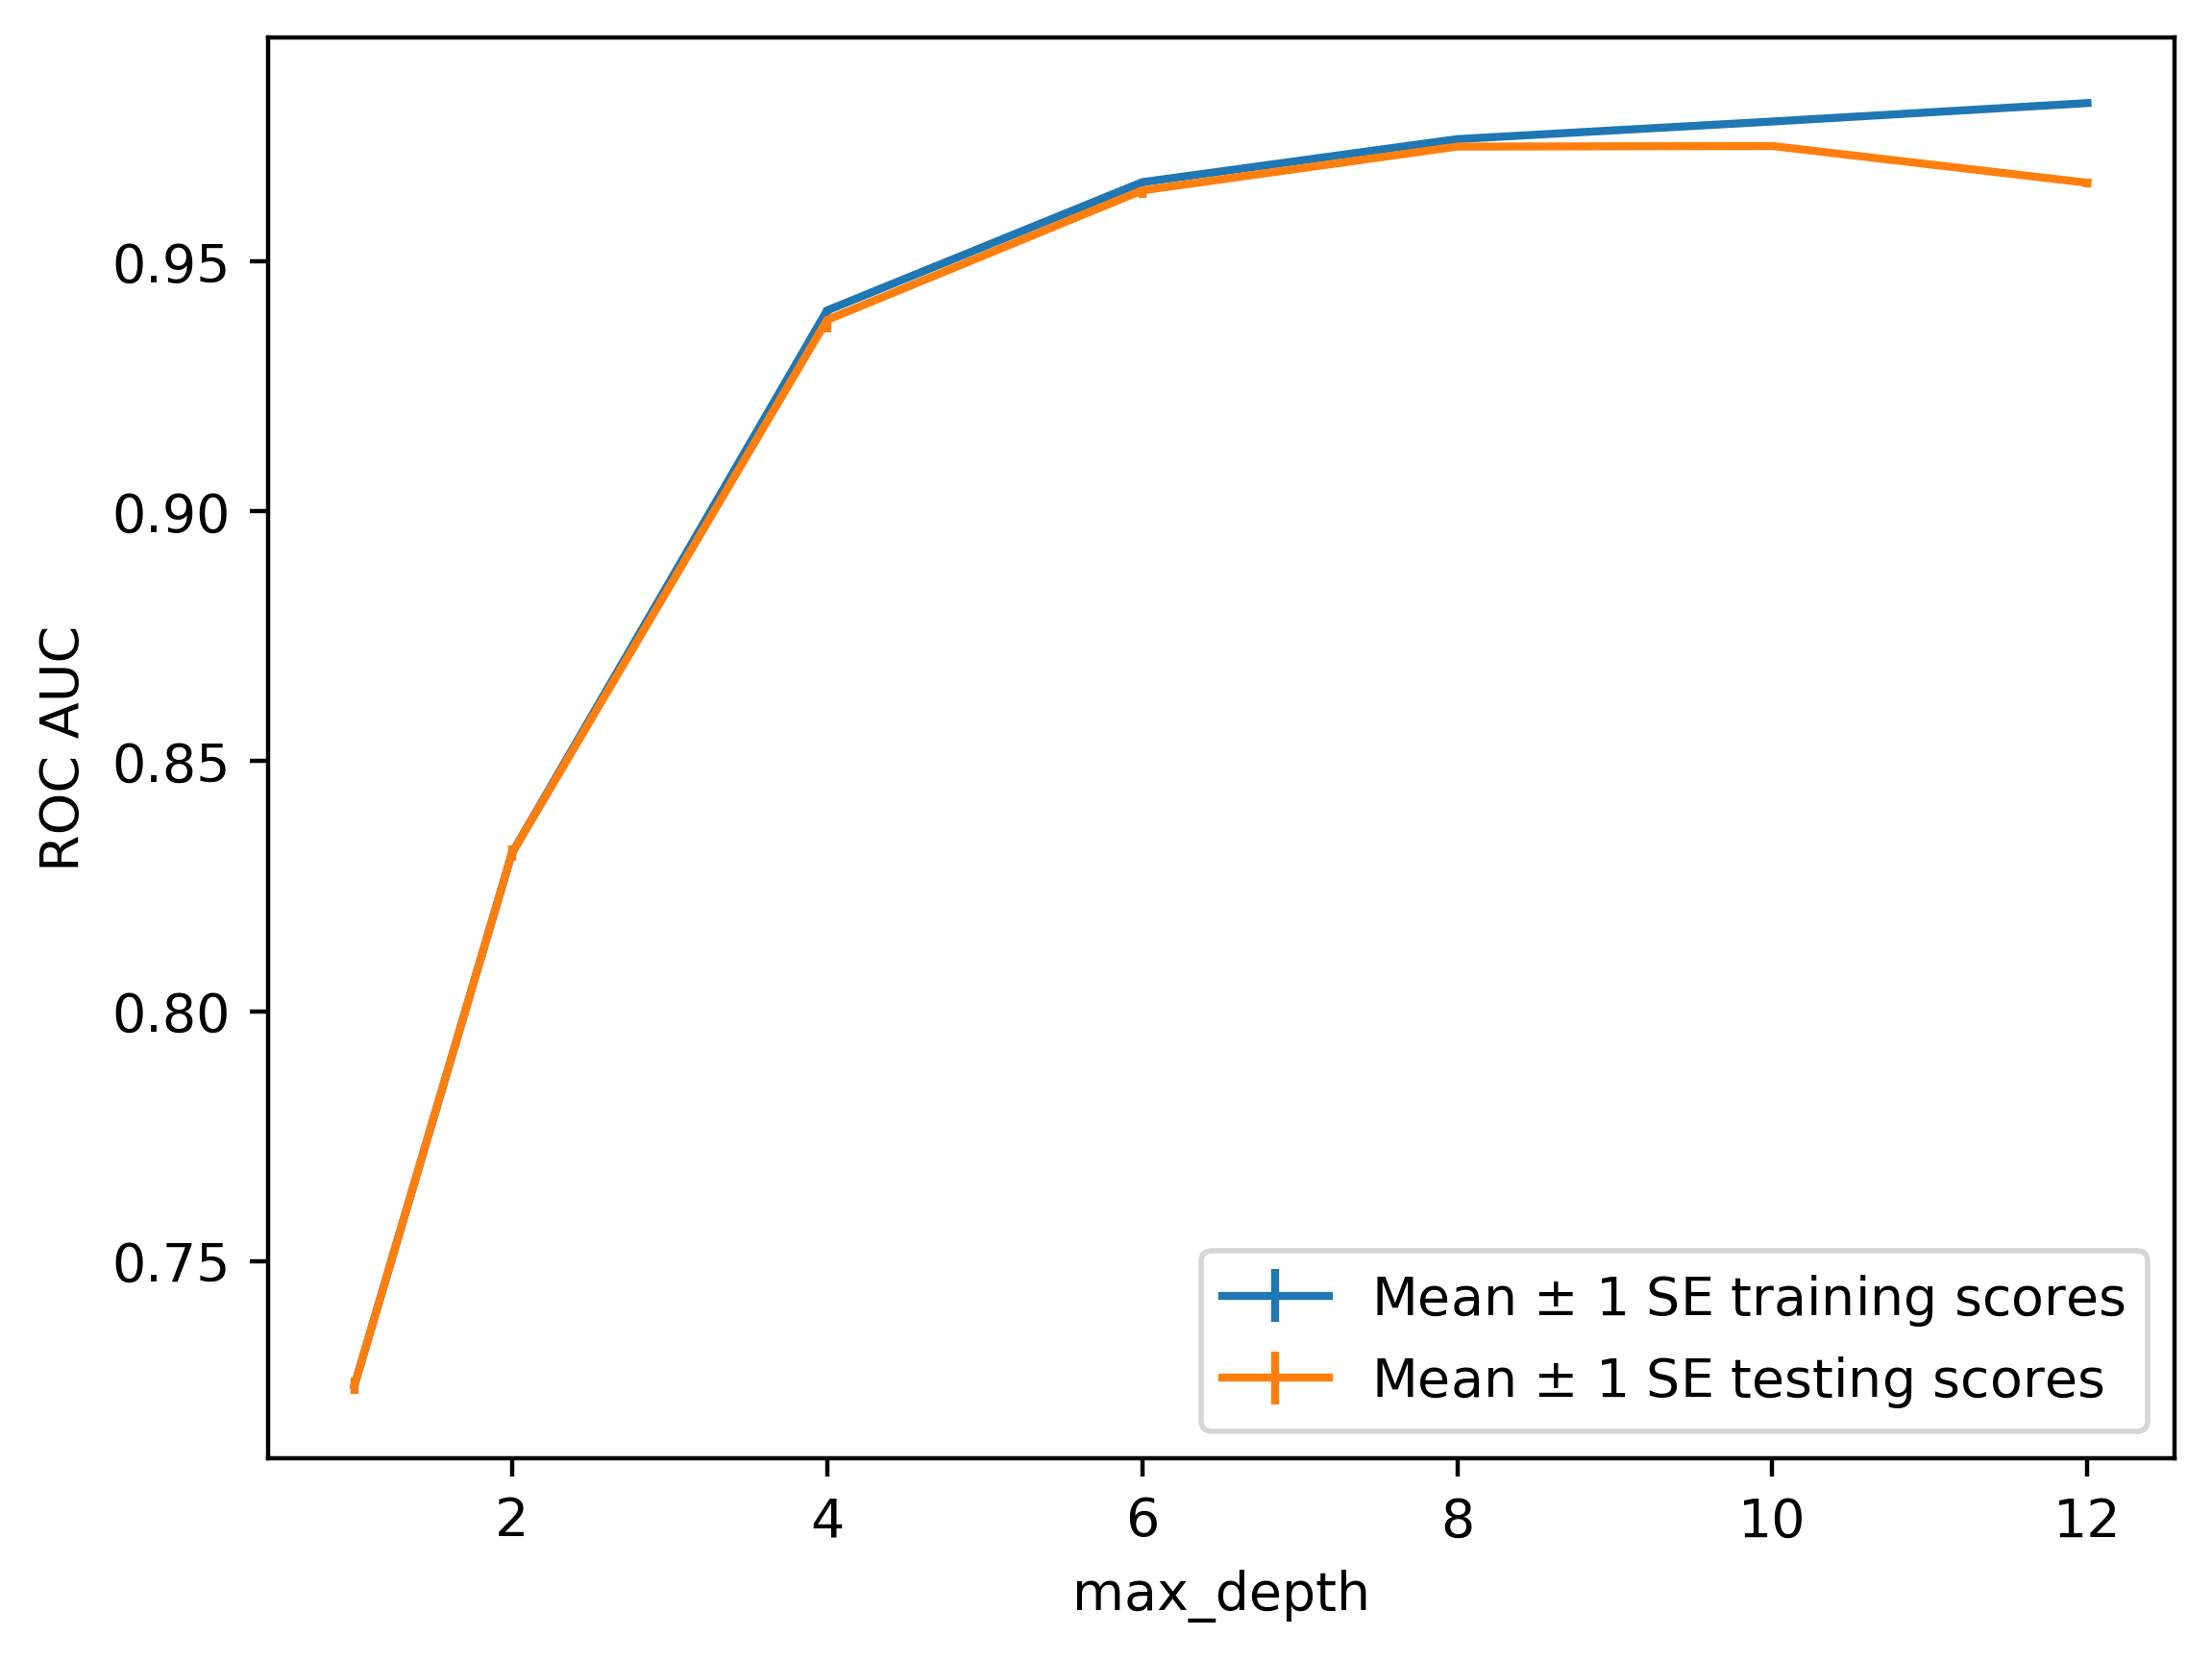

In [ ]:
cv_results_df = pd.DataFrame(cv.cv_results_)
#View the names of the remaining columns in the results DataFrame
cv_results_df.columns
ax = plt.axes()
ax.errorbar(cv_results_df['param_max_depth'],
cv_results_df['mean_train_score'],
yerr=cv_results_df['std_train_score']/np.sqrt(4),
label='Mean $\pm$ 1 SE training scores')
ax.errorbar(cv_results_df['param_max_depth'],
cv_results_df['mean_test_score'],
yerr=cv_results_df['std_test_score']/np.sqrt(4),
label='Mean $\pm$ 1 SE testing scores')
ax.legend()
plt.xlabel('max_depth')
plt.ylabel('ROC AUC')

### Xây dựng rừng cây (Random Forest)

#### 2.8. Tạo rừng cây với lớp RandomForestClassifier trong Scikit-Learn

In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier\
(n_estimators=10, criterion='gini', max_depth=3,
min_samples_split=2, min_samples_leaf=1, min_weight_fraction_leaf=0.0,
max_features='sqrt', max_leaf_nodes=None, min_impurity_decrease=0.0,
bootstrap=True, oob_score=False, n_jobs=None,
random_state=4, verbose=0, warm_start=False, class_weight=None)

#### 2.9. Tìm tham số tối ưu cho mô hình rừng cây và thực hiện train với tham số tối ưu đó

In [ ]:
#a parameter grid for this exercise in order to search the numbers of trees, ranging from 10 to 100 by 10s
rf_params_ex = {'n_estimators':list(range(10,110,10))}
cv_rf_ex = GridSearchCV(rf, param_grid=rf_params_ex,
scoring='roc_auc', n_jobs=None,
refit=True, cv=4, verbose=1,
error_score=np.nan,
return_train_score=True)

cv_rf_ex.fit(X_train, y_train)

Fitting 4 folds for each of 10 candidates, totalling 40 fits


GridSearchCV(cv=4,
             estimator=RandomForestClassifier(max_depth=3, n_estimators=10,
                                              random_state=4),
             param_grid={'n_estimators': [10, 20, 30, 40, 50, 60, 70, 80, 90,
                                          100]},
             return_train_score=True, scoring='roc_auc', verbose=1)

#### 2.10. Vẽ biểu đồ đánh giá mô hình rừng cây với các tham số số cây có trong rừng khác nhau

<>:12: SyntaxWarning: invalid escape sequence '\p'
<>:12: SyntaxWarning: invalid escape sequence '\p'
/tmp/ipython-input-1889697650.py:12: SyntaxWarning: invalid escape sequence '\p'
  axs[1].set_ylabel('Mean testing ROC AUC $\pm$ 1 SE ')


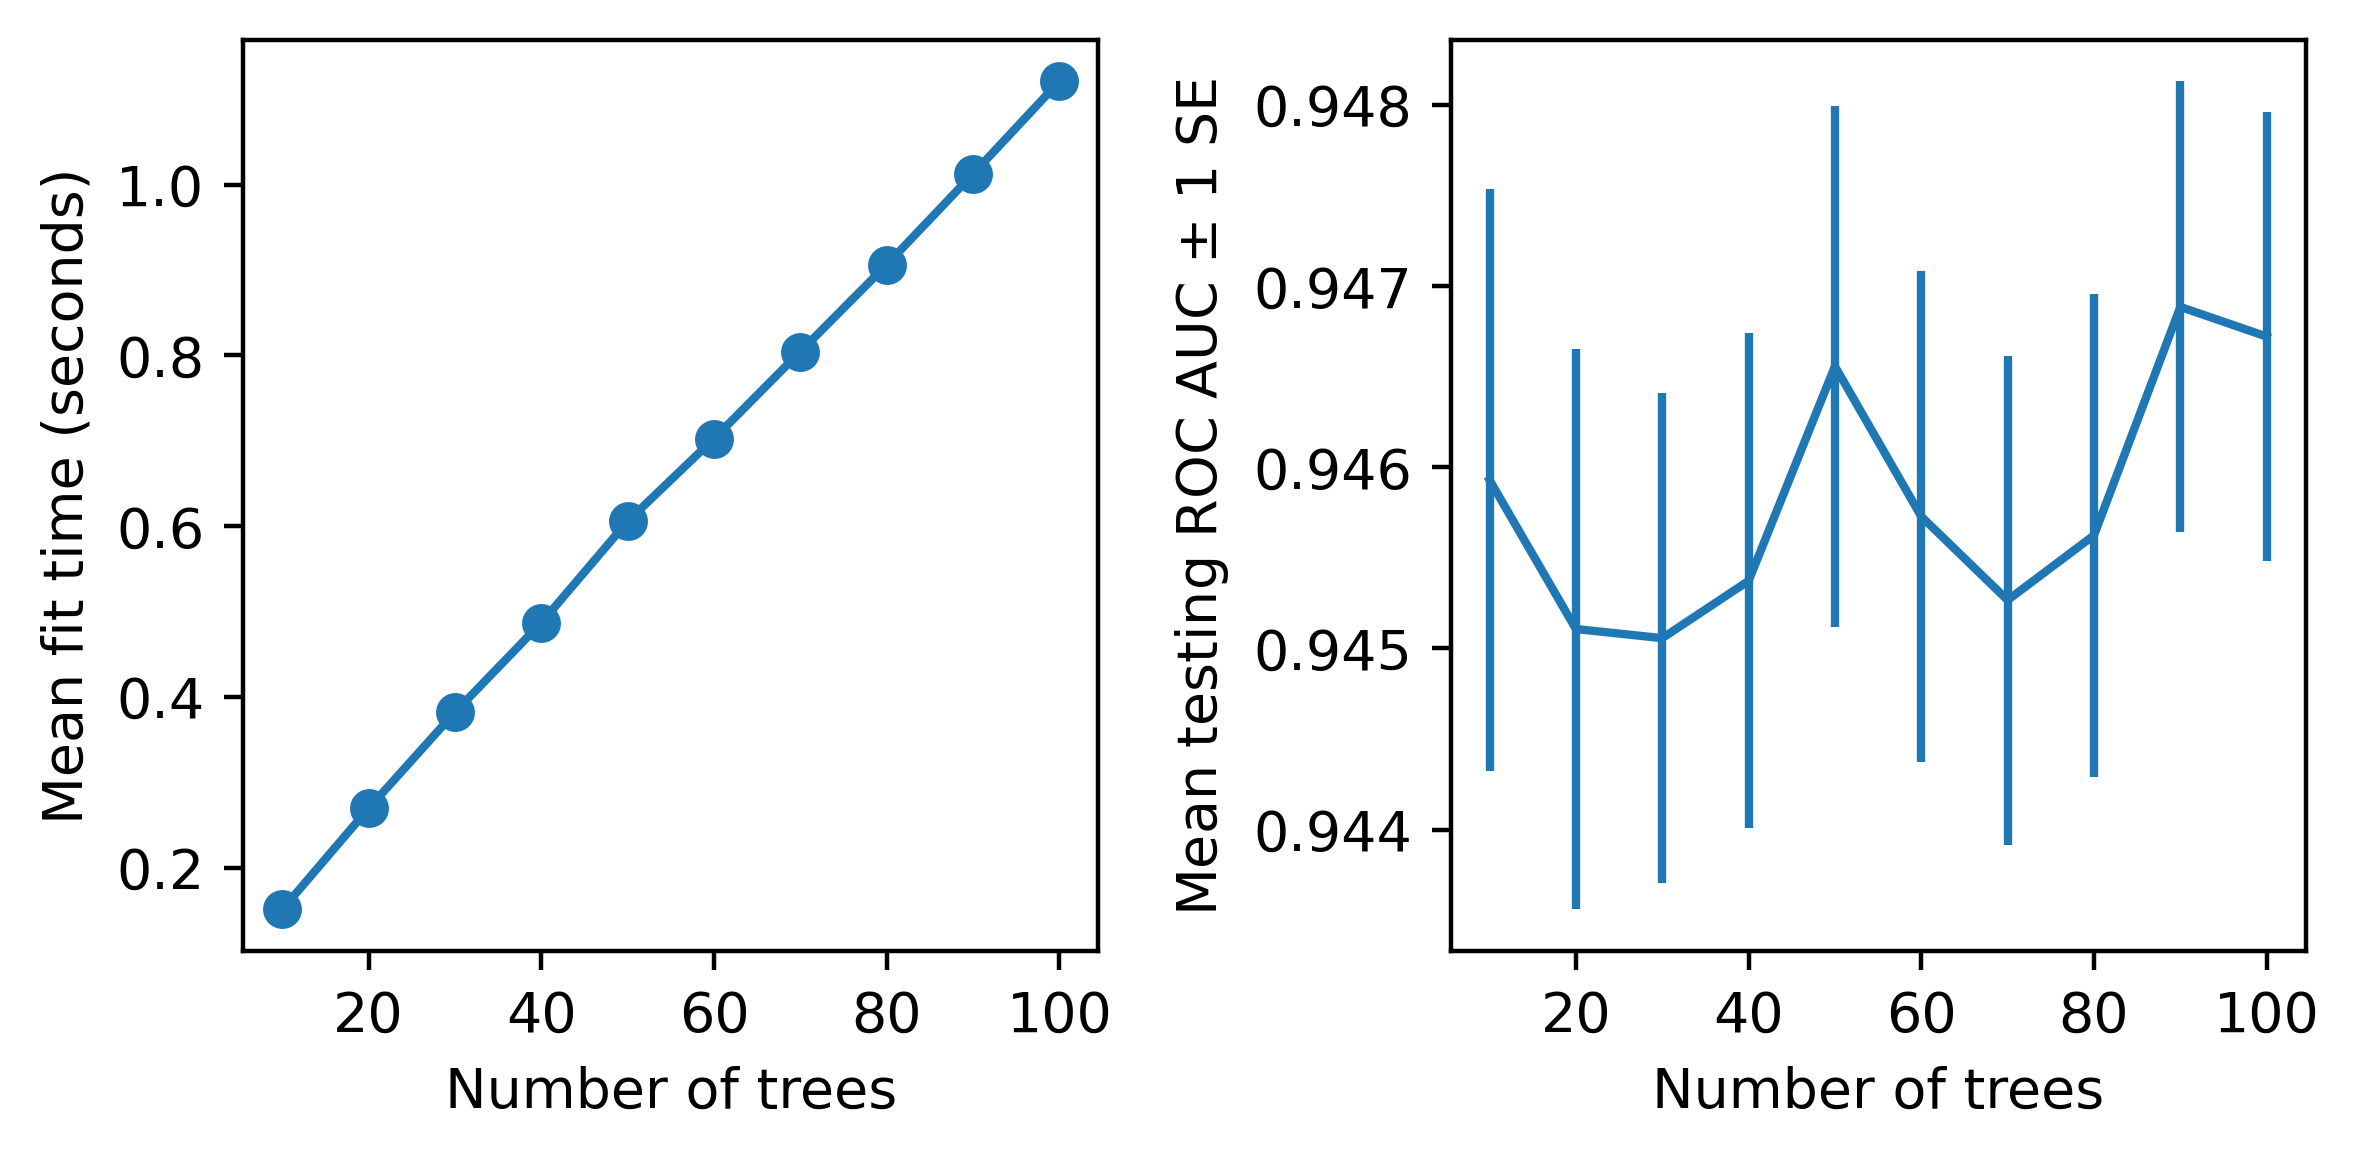

In [ ]:
cv_rf_ex_results_df = pd.DataFrame(cv_rf_ex.cv_results_)
fig, axs = plt.subplots(nrows=1, ncols=2, figsize=(6, 3))
axs[0].plot(cv_rf_ex_results_df['param_n_estimators'],
cv_rf_ex_results_df['mean_fit_time'],
'-o')
axs[0].set_xlabel('Number of trees')
axs[0].set_ylabel('Mean fit time (seconds)')
axs[1].errorbar(cv_rf_ex_results_df['param_n_estimators'],
cv_rf_ex_results_df['mean_test_score'],
yerr=cv_rf_ex_results_df['std_test_score']/np.sqrt(4))
axs[1].set_xlabel('Number of trees')
axs[1].set_ylabel('Mean testing ROC AUC $\pm$ 1 SE ')
plt.tight_layout()

#### 2.11. Xem tham số tốt nhất của rừng cây, xem mức độ quan trọng của từng feature trong mô hình với tham số tốt nhất

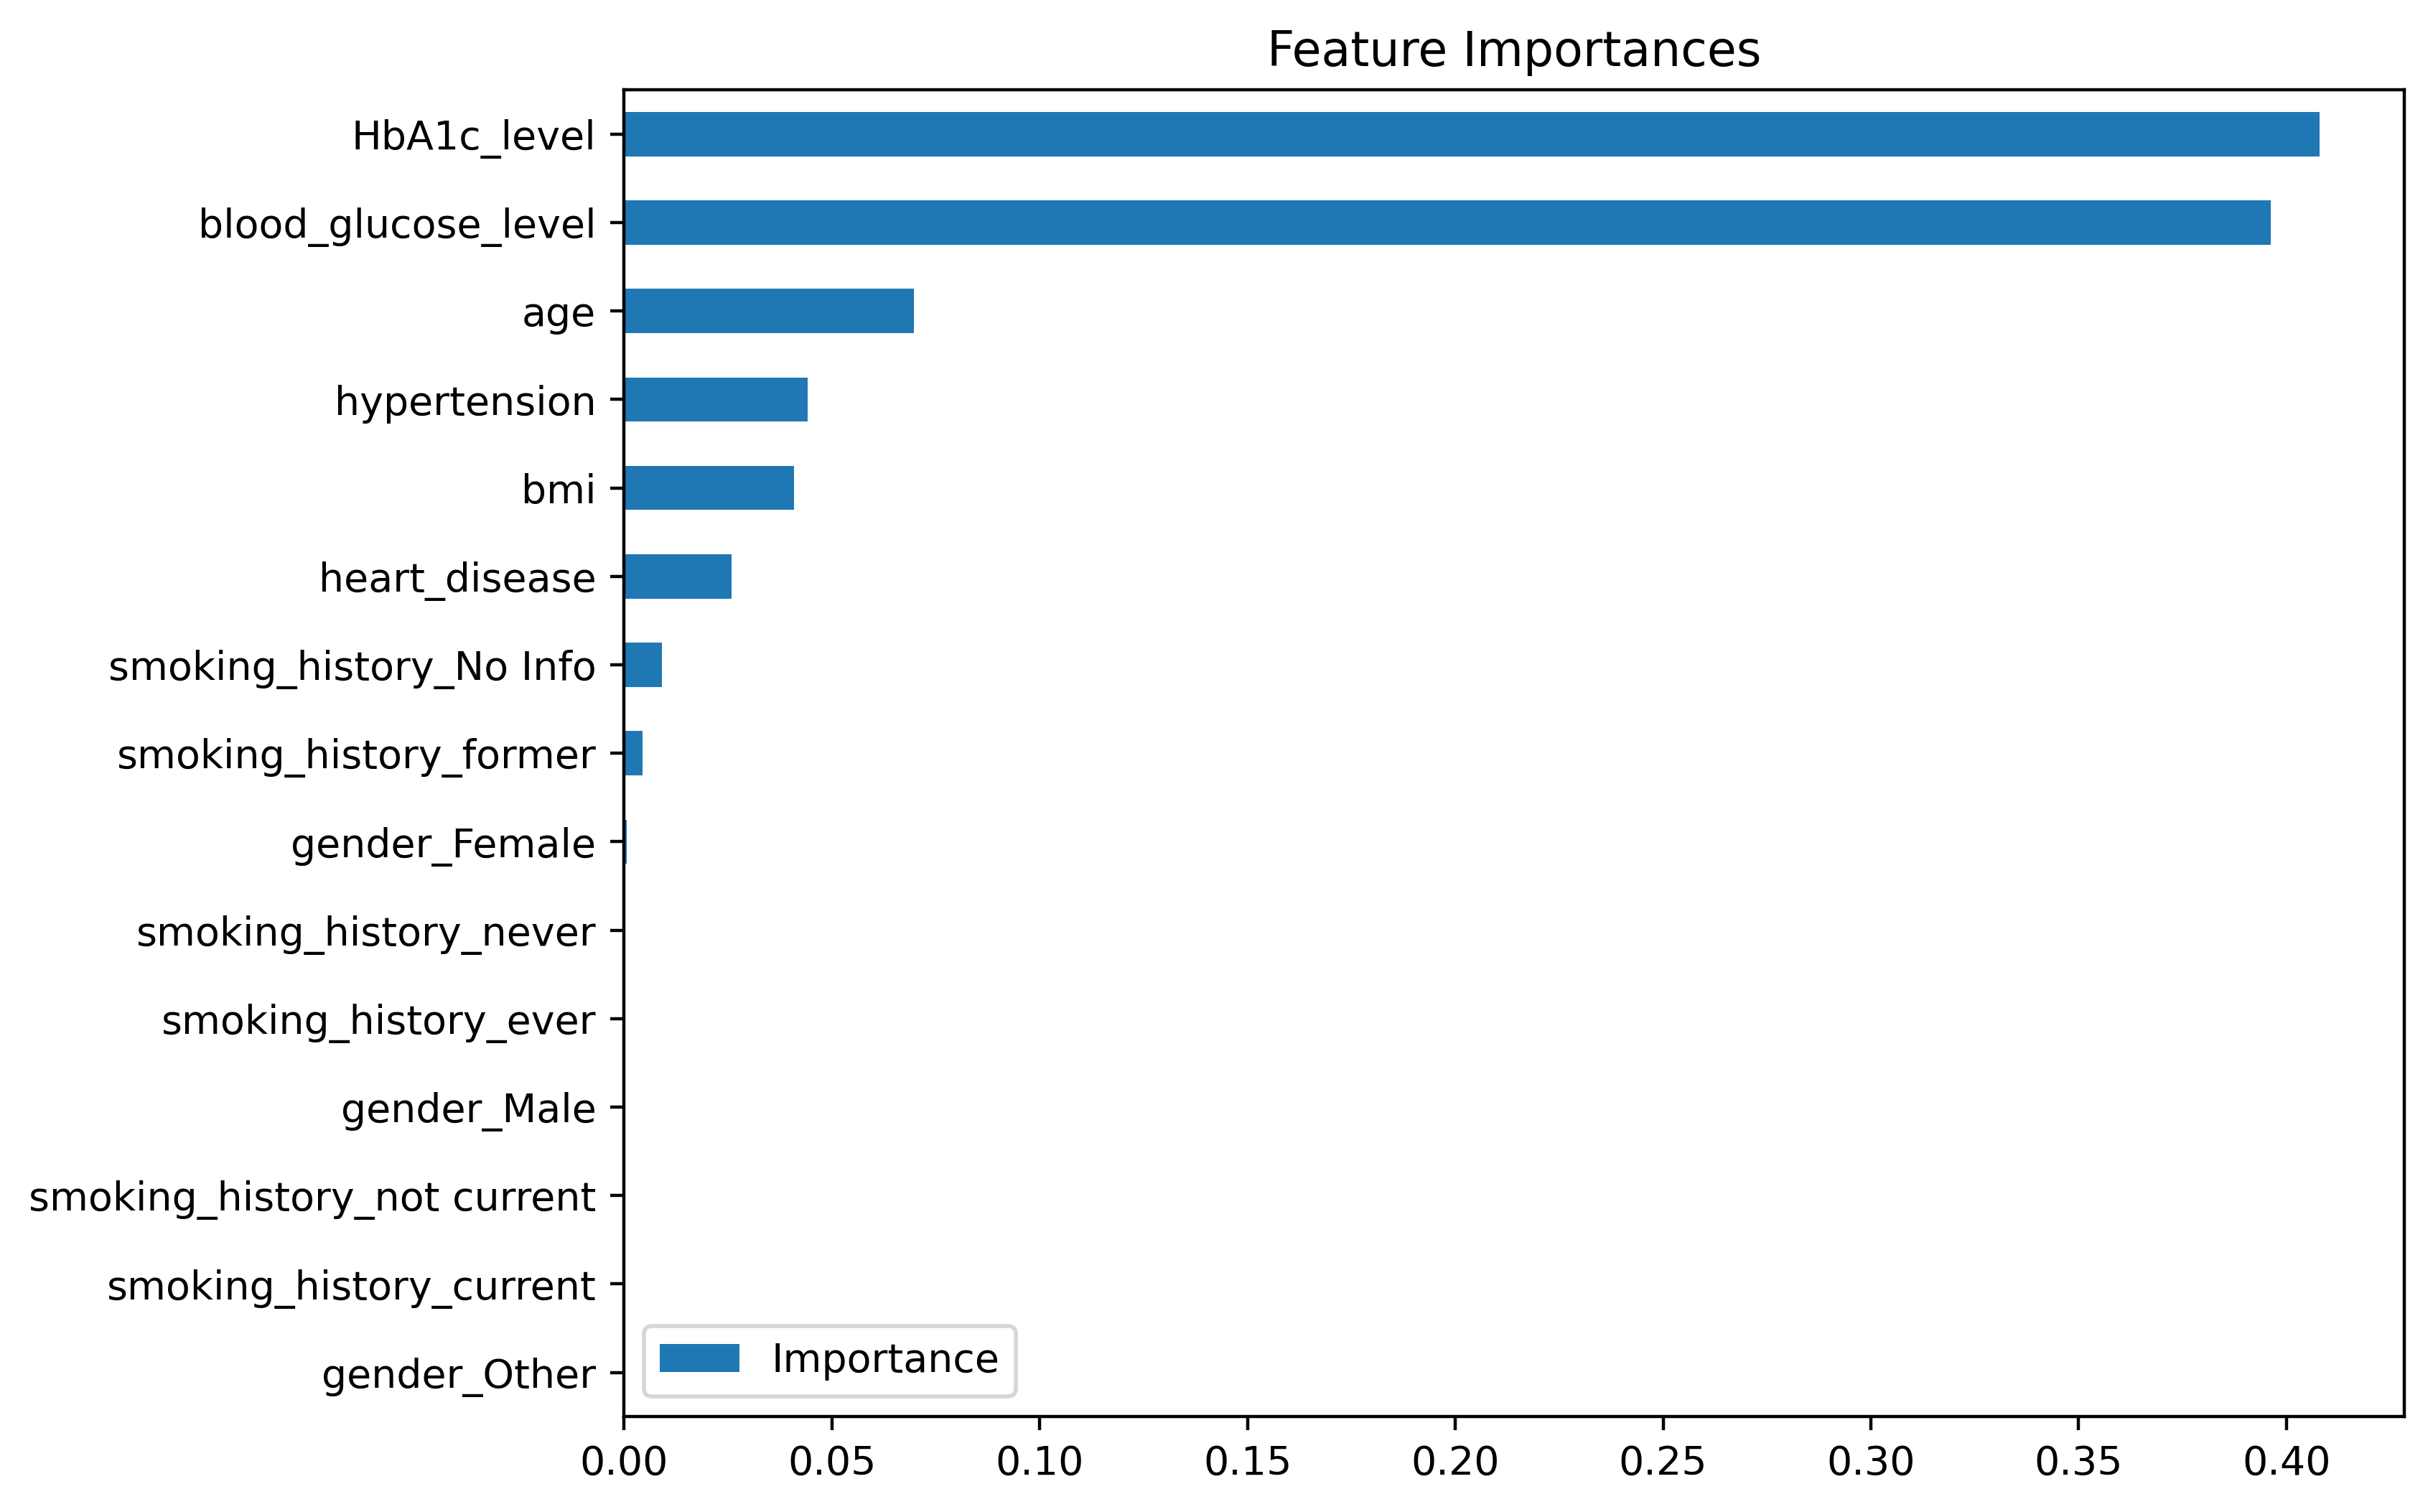

In [ ]:
feature_names = features_encoded.columns.tolist()  # 15 cột

# Tạo DataFrame feature importance
feat_imp_df = pd.DataFrame({
    'Importance': cv_rf_ex.best_estimator_.feature_importances_
}, index=feature_names)

# Vẽ biểu đồ horizontal bar
feat_imp_df.sort_values('Importance', ascending=True).plot.barh(figsize=(8,6))
plt.title("Feature Importances")
plt.show()

# GIẢI THUẬT 2: SUPPORT VECTOR MACHINE (SVM)

## Ôn tập lý thuyết

## Bài tập thực hành

### Bài 1: Xây dựng mô hình từ giải thuật SVM trên dữ liệu bệnh tiểu đường.
Dữ liệu lấy từ: https://www.kaggle.com/code/tumpanjawat/diabetes-eda-random-forest-hp

#### 1.1. Tải dữ liệu về, nạp dữ liệu, xem thông tin các feature có trong tập dữ liệu và chuẩn bị dữ liệu cho xây dựng mô hình

In [ ]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
# # Download&Load dữ liệu df từ datasets của scikit-learn
# df = pd.read_csv('/content/my_data/diabetes/diabetes_prediction_dataset.csv')
# # Hiển thị mô ta dữ liệu, chỉ có trong các bộ dữ liệu chuẩn và mở để học tập và nghiên cứu
# print(df.DESCR)
# # Từ tập dữ liệu ban đầu, tách lấy ma trận biểu diễn các đặc trưng và nhãn.
# data = df['Outcome']
# target = df['.....']
# # TODO: Chia dữ liệu và nhãn thành 2 tập dữ liệu huấn luyện và dữ liệu kiểm tra theo tỉ lệ 80:20
# X_train, X_test, y_train, y_test = train_test_split(data, target,
# test_size = 0.2, random_state=101)

# Load dữ liệu
df = pd.read_csv('/content/my_data/diabetes/diabetes_prediction_dataset.csv')

# Xác định nhãn và đặc trưng
target = df['diabetes']          # Nhãn
data = df.drop(columns=['diabetes'])  # Các đặc trưng

# Encode các cột object
data_encoded = pd.get_dummies(data)  # gender, smoking_history → one-hot

# Scale dữ liệu
scaler = StandardScaler()
data_scaled = scaler.fit_transform(data_encoded)

# Chia dữ liệu train/test 80:20
X_train, X_test, y_train, y_test = train_test_split(
    data_scaled, target, test_size=0.2, random_state=101
)

# Kiểm tra kích thước
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (80000, 15)
X_test: (20000, 15)
y_train: (80000,)
y_test: (20000,)


#### 1.2. Tạo mô hình SVM với dữ liệu đã chuẩn bị

In [ ]:
from sklearn import svm
# khởi tạo mô hình phân lớp
clf = svm.SVC()
# Sử dụng phương thức 'fit' để huấn luyện mô hình với dữ liệu huấn luyện và nhãn huấn luyện
# fit (X,Y) với X là tập các đối tượng, Y là tập nhãn tương ứng của đối tượng.
clf.fit(X_train, y_train)

SVC()

#### 1.3. Đánh giá độ chính xác của mô hình

In [ ]:
# Tính độ chính xác trên tập huấn luyện và tập kiểm tra
train_acc = clf.score(X_train,y_train)
val_acc = clf.score(X_test,y_test)
print('Training accuracy: {}'.format(train_acc))
print('Validation accuracy: {}'.format(val_acc))

Training accuracy: 0.9636625
Validation accuracy: 0.96205


#### 1.4. Tìm tham số kernel tối ưu cho mô hình SVM

In [ ]:
from sklearn import svm
from sklearn.model_selection import train_test_split

kernels = ['linear', 'poly', 'rbf', 'sigmoid']
best_svm = None
best_val_acc = -1
best_kernel = None

X_small = X_train[:2000]
y_small = y_train[:2000]

for k in kernels:
    print(f"Training with kernel = {k}")
    clf = svm.SVC(kernel=k)  # bỏ probability=True để tăng tốc
    clf.fit(X_small, y_small)
    tmp_val_acc = clf.score(X_test, y_test)
    print(f"Accuracy = {tmp_val_acc:.4f}")

    if tmp_val_acc > best_val_acc:
        best_val_acc = tmp_val_acc
        best_svm = clf
        best_kernel = k

print(f"\n✅ Best validation accuracy: {best_val_acc:.4f} with kernel: {best_kernel}")


Training with kernel = linear
Accuracy = 0.9595
Training with kernel = poly
Accuracy = 0.9554
Training with kernel = rbf
Accuracy = 0.9555
Training with kernel = sigmoid
Accuracy = 0.9357

✅ Best validation accuracy: 0.9595 with kernel: linear


### Bài 2: Xây dựng mô hình từ giải thuật SVM trên dữ liệu các con thú trong rừng.
Dữ liệu lấy từ: https://www.kaggle.com/code/kareemellithy/animal-condition-predict-svm-knn

#### 2.1. Tải dữ liệu về, nạp dữ liệu, xem thông tin các feature có trong tập dữ liệu và chuẩn bị dữ liệu cho xây dựng mô hình

In [ ]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
# Download&Load dữ liệu df từ datasets of scikit-learn
df = pd.read_csv('/content/my_data/animal/data.csv')
# Hiển thị mô ta dữ liệu, chỉ có trong các bộ dữ liệu chuẩn và mở để học tập và nghiên cứu
print(df.head())
# Từ tập dữ liệu ban đầu, tách lấy ma trận biểu diễn các đặc trưng và nhãn.
data = df.iloc[:, :-1]
target = df['Dangerous']

# Handle missing values before splitting and encoding
for col in data.columns:
    if data[col].dtype == 'object':
        data[col].fillna(data[col].mode()[0], inplace=True)
    else:
        data[col].fillna(data[col].mean(), inplace=True)

# TODO: Chia dữ liệu và nhãn thành 2 tập dữ liệu huấn luyện và dữ liệu kiểm tra theo tỉ lệ 80:20
X_train, X_test, y_train, y_test = train_test_split(data, target,
test_size = 0.2, random_state=101)


  AnimalName symptoms1             symptoms2 symptoms3    symptoms4  \
0        Dog     Fever              Diarrhea  Vomiting  Weight loss   
1        Dog     Fever              Diarrhea  Coughing    Tiredness   
2        Dog     Fever              Diarrhea  Coughing     Vomiting   
3        Dog     Fever  Difficulty breathing  Coughing     Lethargy   
4        Dog     Fever              Diarrhea  Coughing     Lethargy   

     symptoms5 Dangerous  
0  Dehydration       Yes  
1        Pains       Yes  
2     Anorexia       Yes  
3     Sneezing       Yes  
4     Blue Eye       Yes  


/tmp/ipython-input-3177598026.py:15: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data[col].fillna(data[col].mode()[0], inplace=True)
/tmp/ipython-input-3177598026.py:15: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data[col].fillna(data[col].mode()[0], inplace=True)


#### 2.2. Tạo mô hình SVM với dữ liệu đã chuẩn bị

In [ ]:
from sklearn import svm
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder

# Load and preprocess data (assuming missing values handled in the previous cell)
# One-hot encode the entire data DataFrame *before* splitting
data_encoded = pd.get_dummies(data)

# Scale the encoded data
scaler = StandardScaler()
data_scaled = scaler.fit_transform(data_encoded)

# Encode the target variable
le = LabelEncoder()
target_encoded = le.fit_transform(target)


# Split the scaled and encoded data into train/test sets
X_train, X_test, y_train, y_test = train_test_split(data_scaled, target_encoded, test_size=0.2, random_state=101)


# B5. Khởi tạo và huấn luyện mô hình
clf = svm.SVC(kernel='rbf')
clf.fit(X_train, y_train)

print("✅ Mô hình SVM đã được huấn luyện thành công!")

✅ Mô hình SVM đã được huấn luyện thành công!


#### 2.3. Đánh giá độ chính xác của mô hình

In [ ]:
# Tính độ chính xác trên tập huấn luyện và tập kiểm tra
train_acc = clf.score(X_train,y_train)
val_acc = clf.score(X_test,y_test)
print('Training accuracy: {}'.format(train_acc))
print('Validation accuracy: {}'.format(val_acc))

Training accuracy: 0.9913793103448276
Validation accuracy: 0.9542857142857143


#### 2.4. Tìm tham số kernel tối ưu cho mô hình SVM

In [ ]:
# best_svm, best_val_acc và best_kernel lần lượt là các biến lưu mô hình tốt nhất,
# độ chính xác cao nhất trên tập kiểm tra và kernel tốt nhất
kernels = ['linear', 'poly', 'rbf', 'sigmoid']
best_svm = None
best_val_acc = -1
best_kernel = None
# Huấn luyện các mô hình dựa trên dữ liệu huấn luyện và tham số kernel
# Tính toán độ chính xác trên tập huấn luyện và tập kiểm tra để tìm được mô hình tốt nhất
for i in range(4):
  clf = svm.SVC(kernel=kernels[i], probability=True)
  clf.fit(X_train, y_train)
  tmp_val_acc = clf.score(X_test, y_test)
  if (tmp_val_acc > best_val_acc):
    best_val_acc = tmp_val_acc
    best_svm = clf
    best_kernel = kernels[i]
# Hiển thị mô hình tốt nhất cùng với độ chính xác
print("Best validation accuracy : {} with kernel: {}".format(best_val_acc,
best_kernel))

Best validation accuracy : 0.9885714285714285 with kernel: linear


# GIẢI THUẬT 3: BAYES NGÂY THƠ (NAÏVE BAYES)

## Ôn tập lý thuyết

## Bài tập thực hành

### Bài 1: Xây dựng mô hình Naïve ngây thơ trên tập dữ liệu hành vi của khách hàng
lấy tại: https://www.kaggle.com/code/arezalo/customer-behaviour-prediction-naive-bayes

#### 1.1. Import thư viện và nạp dữ liệu vào notebook

In [ ]:
#Importing the Necessary libraries
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
data = pd.read_csv('my_data/customer_behaviour/Customer_Behaviour.csv')
#display the first 5 rows
data.head(10)

,User ID,Gender,Age,EstimatedSalary,Purchased
0,15624510,Male,19,19000,0
1,15810944,Male,35,20000,0
2,15668575,Female,26,43000,0
3,15603246,Female,27,57000,0
4,15804002,Male,19,76000,0
5,15728773,Male,27,58000,0
6,15598044,Female,27,84000,0
7,15694829,Female,32,150000,1
8,15600575,Male,25,33000,0
9,15727311,Female,35,65000,0


#### 1.2. Xử lý dữ liệu trước khi xây dựng mô hình từ dữ liệu

In [ ]:

# Rename columns for clarity:
# data.columns = ['....', '....']
# Separate features (X) and target labels (y)
X = data.drop(columns=['User ID','Purchased'], axis=1)
y = data['Purchased']
# Split the data into training and testing sets (80% training, 20% testing)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2,
random_state=42)

#### 1.3. Xây dựng vector hóa nội dung HAM | SPAM của tập train và tập test

In [ ]:
from sklearn.feature_extraction.text import CountVectorizer
vectorizer = CountVectorizer()

transfrom_cols = ['Gender']
for col in transfrom_cols:
  # Fit and transform the training data (X_train)
  X_train_vectorized = vectorizer.fit_transform(X_train[col])
  # Transform the test data (X_test)
  X_test_vectorized = vectorizer.transform(X_test[col])

#### 1.4. Xây dựng mô hình Naïve Bayes

In [ ]:
from sklearn.naive_bayes import MultinomialNB
classifier = MultinomialNB()
classifier.fit(X_train_vectorized, y_train)

MultinomialNB()

#### 1.5. Đánh giá hiệu quả của mô hình

In [ ]:
from sklearn.metrics import accuracy_score, confusion_matrix,classification_report
# Make predictions on the test data
y_pred = classifier.predict(X_test_vectorized)
# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)
classification_rep = classification_report(y_test, y_pred)
print(f"Accuracy: {accuracy:.2f}")
print("Confusion Matrix:")
print(conf_matrix)
print("Classification Report:")
print(classification_rep)

Accuracy: 0.65
Confusion Matrix:
[[52  0]
 [28  0]]
Classification Report:
              precision    recall  f1-score   support

           0       0.65      1.00      0.79        52
           1       0.00      0.00      0.00        28

    accuracy                           0.65        80
   macro avg       0.33      0.50      0.39        80
weighted avg       0.42      0.65      0.51        80



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


### Bài 2: Xây dựng mô hình Naïve ngây thơ trên tập dữ liệu mushroom.
Dữ liệu lấy tại: https://www.kaggle.com/datasets/uciml/mushroom-classification/data

#### 2.1. Import thư viện và nạp dữ liệu vào notebook

In [ ]:
#Importing the Necessary libraries
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, confusion_matrix,classification_report
data = pd.read_csv('my_data/mushroom/mushrooms.csv')
#display the first 5 rows
data.head()

,class,cap-shape,cap-surface,cap-color,bruises,odor,gill-attachment,gill-spacing,gill-size,gill-color,...,stalk-surface-below-ring,stalk-color-above-ring,stalk-color-below-ring,veil-type,veil-color,ring-number,ring-type,spore-print-color,population,habitat
0,p,x,s,n,t,p,f,c,n,k,...,s,w,w,p,w,o,p,k,s,u
1,e,x,s,y,t,a,f,c,b,k,...,s,w,w,p,w,o,p,n,n,g
2,e,b,s,w,t,l,f,c,b,n,...,s,w,w,p,w,o,p,n,n,m
3,p,x,y,w,t,p,f,c,n,n,...,s,w,w,p,w,o,p,k,s,u
4,e,x,s,g,f,n,f,w,b,k,...,s,w,w,p,w,o,e,n,a,g


In [ ]:
data.columns

Index(['class', 'cap-shape', 'cap-surface', 'cap-color', 'bruises', 'odor',
       'gill-attachment', 'gill-spacing', 'gill-size', 'gill-color',
       'stalk-shape', 'stalk-root', 'stalk-surface-above-ring',
       'stalk-surface-below-ring', 'stalk-color-above-ring',
       'stalk-color-below-ring', 'veil-type', 'veil-color', 'ring-number',
       'ring-type', 'spore-print-color', 'population', 'habitat'],
      dtype='object')

#### 2.2. Xử lý dữ liệu trước khi xây dựng mô hình từ dữ liệu

In [ ]:
# Drop the columns with NaN values
# data = data.drop(columns=['.....', '......', '.......'], axis=1)
# Rename columns for clarity:
# data.columns = ['....', '....']
# Separate features (X) and target labels (y)
y = data['class']
data = data.drop(columns=['class'], axis=1)
data_encoded = pd.get_dummies(data, drop_first=True)
X = data_encoded

# Split the data into training and testing sets (80% training, 20% testing)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2,
random_state=42)

#### 2.3. Xây dựng vector hóa nội dung HAM | SPAM của tập train và tập test

#### 2.4. Xây dựng mô hình Naïve Bayes

In [ ]:
from sklearn.naive_bayes import MultinomialNB
classifier = MultinomialNB()
classifier.fit(X_train, y_train)

MultinomialNB()

#### 2.5. Đánh giá hiệu quả của mô hình

In [ ]:
from sklearn.metrics import accuracy_score, confusion_matrix,classification_report
# Make predictions on the test data
y_pred = classifier.predict(X_test)
# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)
classification_rep = classification_report(y_test, y_pred)
print(f"Accuracy: {accuracy:.2f}")
print("Confusion Matrix:")
print(conf_matrix)
print("Classification Report:")
print(classification_rep)

Accuracy: 0.95
Confusion Matrix:
[[835   8]
 [ 71 711]]
Classification Report:
              precision    recall  f1-score   support

           e       0.92      0.99      0.95       843
           p       0.99      0.91      0.95       782

    accuracy                           0.95      1625
   macro avg       0.96      0.95      0.95      1625
weighted avg       0.95      0.95      0.95      1625

